In [ ]:
import os
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [24]:
current_dir = Path.cwd()
gesture_data_dir = current_dir.parent.parent / "data" / "gesture"

# Loading the dataset

In [25]:
gestures = []
labels = []

for file in os.listdir(gesture_data_dir):
    if file.endswith(".csv"):
        label = file.split("_")[0]
        df = pd.read_csv(os.path.join(gesture_data_dir, file))
        gestures.append(df.values.astype(float))
        labels.append(label)

print(f"Loaded {len(gestures)} gestures.")

Loaded 228 gestures.


# Check if there is any disbalance of classes

Labels distribution:
  i-love-you: 30 (13.16%) | Ratio: 1.88
  excuse-me: 16 (7.02%) | Ratio: 1.00
  hello: 30 (13.16%) | Ratio: 1.88
  please: 40 (17.54%) | Ratio: 2.50
  good-morning: 30 (13.16%) | Ratio: 1.88
  good-afternoon: 22 (9.65%) | Ratio: 1.38
  thank-you: 30 (13.16%) | Ratio: 1.88
  i-am-fine: 30 (13.16%) | Ratio: 1.88


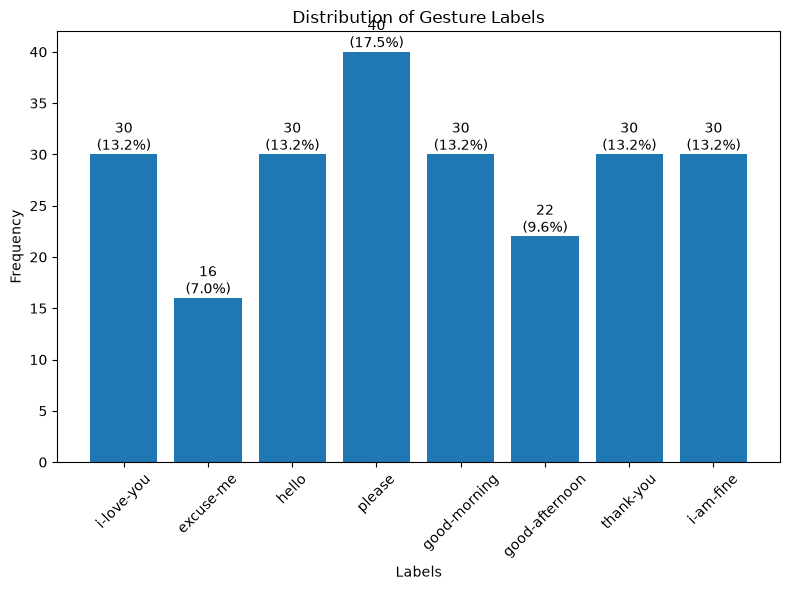

In [26]:
counts = Counter(labels)
total = len(labels)
min_count = min(counts.values())

print("Labels distribution:")

for label, count in counts.items():
    percentage = count / total * 100
    ratio = count / min_count

    print(
        f"  {label}: "
        f"{count} ({percentage:.2f}%) "
        f"| Ratio: {ratio:.2f}"
    )


plt.figure(figsize=(8, 6))

bars = plt.bar(counts.keys(), counts.values())

plt.xlabel("Labels")
plt.ylabel("Frequency")
plt.title("Distribution of Gesture Labels")
plt.xticks(rotation=45)

for bar, count in zip(bars, counts.values()):
    percentage = count / total * 100

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{count}\n({percentage:.1f}%)",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

The classes are moderately imbalanced, with a 2.5:1 ratio between the largest and smallest classes. The imbalance is not severe, so oversampling or undersampling is not necessary. However, per-class metrics should be considered alongside overall accuracy.

# Checking for properties equality

In [27]:
column_sizes = Counter([gesture.shape[1] for gesture in gestures])
column_sizes

Counter({18: 228})

We can see that every gesture has 18 properties because we use 3 mpu6050 sensors where each one produce 6 properties: Accelerometer (X, Y, Z) and Gyroscope (X, Y, Z).

# Checking the distribution of length of every sample

Minimal length: 131 (label: i-am-fine)
Maximum length: 321 (label: i-love-you)
Average length: 220.08
Median length: 223.0


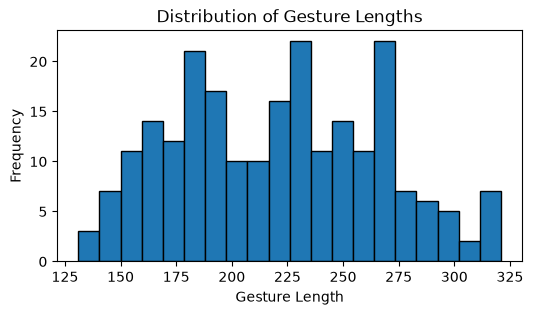

In [28]:
lengths = np.array([len(gesture) for gesture in gestures])

print(f"Minimal length: {lengths.min()} (label: {labels[lengths.argmin()]})")
print(f"Maximum length: {lengths.max()} (label: {labels[lengths.argmax()]})")
print(f"Average length: {lengths.mean():.2f}")
print(f"Median length: {np.median(lengths)}")

plt.figure(figsize=(6, 3))
plt.hist(lengths, bins=20, edgecolor='black')
plt.xlabel("Gesture Length")
plt.ylabel("Frequency")
plt.title("Distribution of Gesture Lengths")
plt.show()

# Checking how every gesture looks like

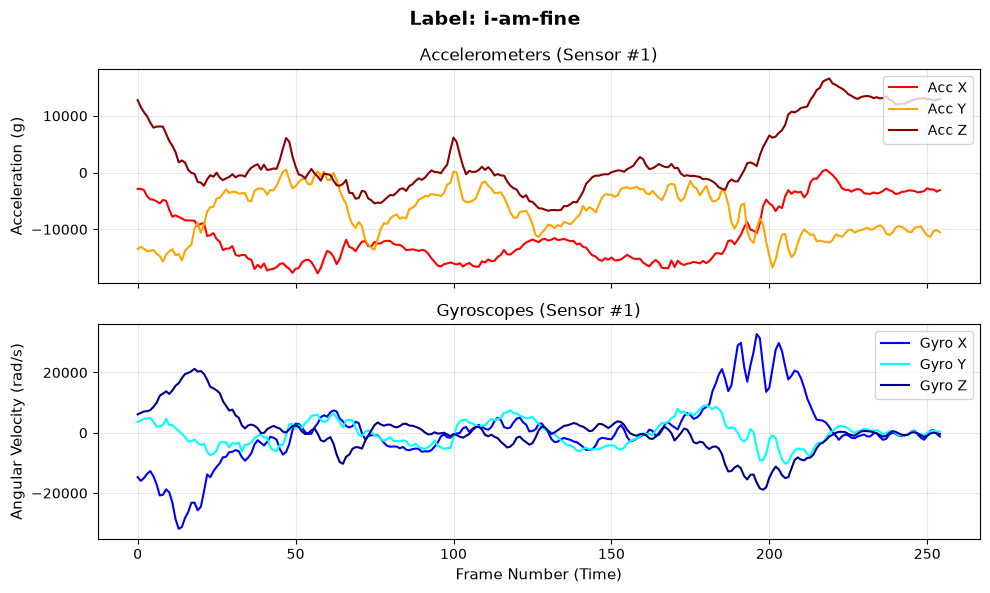

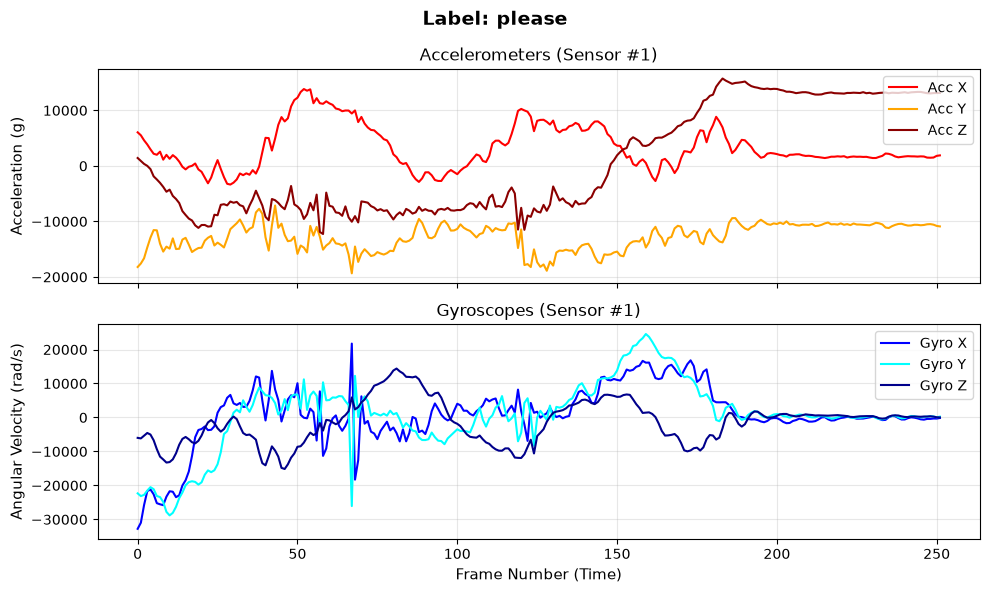

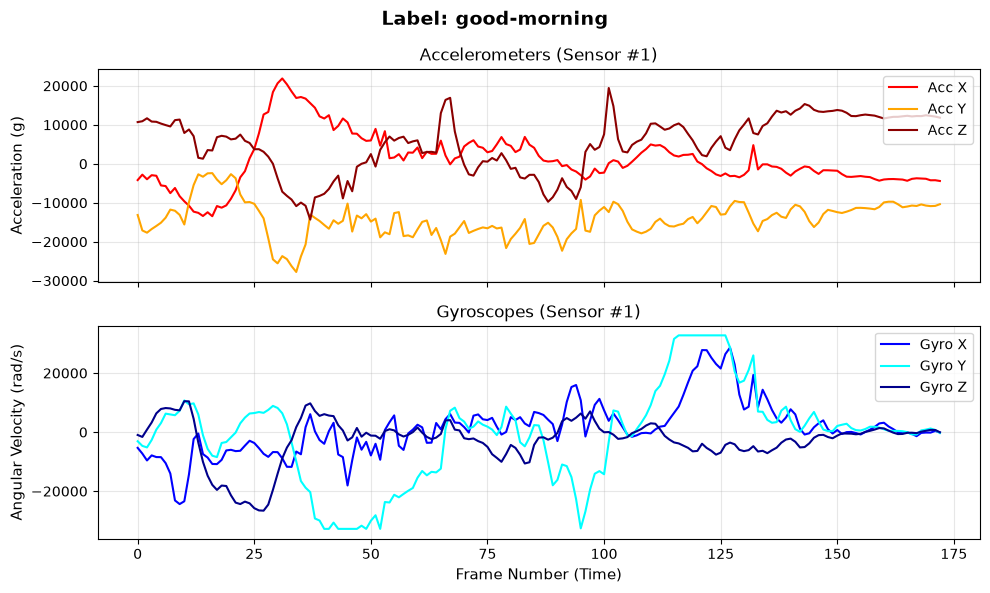

In [29]:
import random

random.seed(42)

for _ in range(3):
    idx = random.randint(0, len(gestures) - 1)
    gesture = pd.DataFrame(gestures[idx])
    label = labels[idx]

    fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
    fig.suptitle(f"Label: {label}", fontsize=14, fontweight='bold')
    
    # We take the first 6 columns (3 accelerometer + 3 gyroscope) from gesture
    colors = ['red', 'orange', 'darkred', 'blue', 'cyan', 'darkblue']
    names = ['Acc X', 'Acc Y', 'Acc Z', 'Gyro X', 'Gyro Y', 'Gyro Z']
    
    # Top plot: accelerometers
    ax1 = axes[0]
    for i in range(3):
        if i < len(gesture.columns):
            ax1.plot(gesture.iloc[:, i], color=colors[i], label=names[i], linewidth=1.5)
    ax1.set_ylabel('Acceleration (g)', fontsize=11)
    ax1.set_title('Accelerometers (Sensor #1)', fontsize=12)
    ax1.legend(loc='upper right')
    ax1.grid(True, alpha=0.3)
    
    # Bottom plot: gyroscope
    ax2 = axes[1]
    for i in range(3, 6):
        if i < len(gesture.columns):
            ax2.plot(gesture.iloc[:, i], color=colors[i], label=names[i], linewidth=1.5)
    ax2.set_ylabel('Angular Velocity (rad/s)', fontsize=11)
    ax2.set_title('Gyroscopes (Sensor #1)', fontsize=12)
    ax2.set_xlabel('Frame Number (Time)', fontsize=11)
    ax2.legend(loc='upper right')
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()

# Analyzing features


CONCATENATED DATA
Shape: (50179, 18)

OVERALL FEATURE VALUES
Min:    -32768.0000
Max:    32767.0000
Mean:   804.3675
Median: 293.0000
Std:    10155.9532

PER-FEATURE STATISTICS
        min      max          mean   median           std
0  -23416.0  24252.0  -4176.537277  -3848.0   5891.045057
1  -32768.0  30800.0 -10737.246099 -11060.0   5336.854146
2  -28876.0  32767.0   3335.419040   3796.0   9049.884738
3  -32768.0  32767.0    638.603340    -56.0  10561.677244
4  -32768.0  32767.0   -633.957990     63.0  10322.881721
5  -32768.0  32767.0   -250.153670     -2.0   6804.737639
6  -32768.0  32767.0   1291.080552   2040.0   8963.698051
7  -32768.0  32767.0   3197.946751   4184.0   9638.502913
8  -32768.0  32767.0  10417.960282  11092.0   5887.511851
9  -32768.0  32767.0    318.297973   -374.0   9644.654892
10 -32768.0  32767.0   -113.465812   -318.0   9735.150651
11 -32768.0  32767.0    166.257937    176.0  13261.984703
12 -32768.0  32767.0   5146.572052   6052.0   7370.762022
13 -32768.

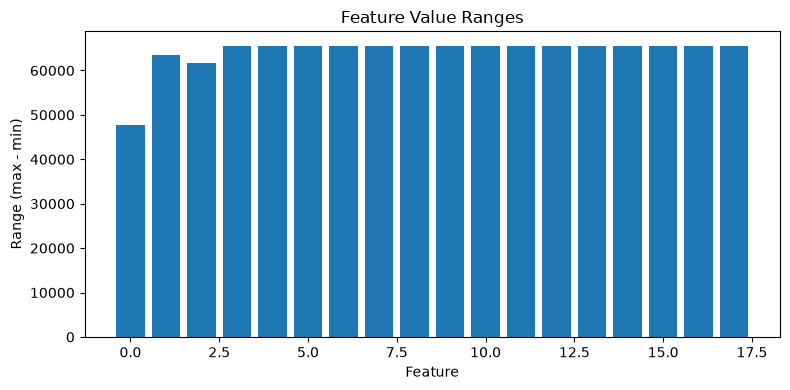

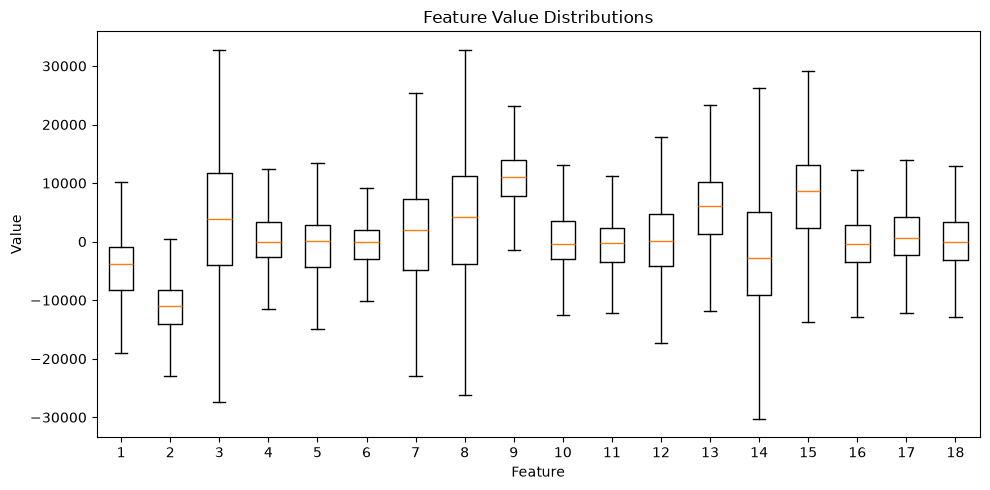

In [30]:
X_all = np.concatenate(gestures, axis=0)

print("\n" + "=" * 60)
print("CONCATENATED DATA")
print("=" * 60)

print(f"Shape: {X_all.shape}")


print("\n" + "=" * 60)
print("OVERALL FEATURE VALUES")
print("=" * 60)

print(f"Min:    {X_all.min():.4f}")
print(f"Max:    {X_all.max():.4f}")
print(f"Mean:   {X_all.mean():.4f}")
print(f"Median: {np.median(X_all):.4f}")
print(f"Std:    {X_all.std():.4f}")


feature_stats = pd.DataFrame({
    "min": np.min(X_all, axis=0),
    "max": np.max(X_all, axis=0),
    "mean": np.mean(X_all, axis=0),
    "median": np.median(X_all, axis=0),
    "std": np.std(X_all, axis=0),
})

print("\n" + "=" * 60)
print("PER-FEATURE STATISTICS")
print("=" * 60)

print(feature_stats.to_string())


print("\n" + "=" * 60)
print("DATA QUALITY")
print("=" * 60)

nan_count = np.isnan(X_all).sum()
inf_count = np.isinf(X_all).sum()

print(f"NaN values: {nan_count}")
print(f"Inf values: {inf_count}")


print("\n" + "=" * 60)
print("FEATURE VARIANCE")
print("=" * 60)

feature_std = np.std(X_all, axis=0)

print(f"Minimum feature std: {feature_std.min():.6f}")
print(f"Maximum feature std: {feature_std.max():.6f}")

low_variance_features = np.where(feature_std < 1e-6)[0]

print(f"Near-constant features: {len(low_variance_features)}")

if len(low_variance_features) > 0:
    print("Feature indices:", low_variance_features)


# Feature ranges

feature_ranges = feature_stats["max"] - feature_stats["min"]

plt.figure(figsize=(8, 4))

plt.bar(
    np.arange(len(feature_ranges)),
    feature_ranges
)

plt.xlabel("Feature")
plt.ylabel("Range (max - min)")
plt.title("Feature Value Ranges")

plt.tight_layout()
plt.show()


# Feature distributions

plt.figure(figsize=(10, 5))

plt.boxplot(
    X_all,
    showfliers=False
)

plt.xlabel("Feature")
plt.ylabel("Value")
plt.title("Feature Value Distributions")

plt.tight_layout()
plt.show()

The dataset contains 50,179 observations and 18 features. No NaN or infinite values were found, and all features have sufficient variance. However, the features have large and different value ranges, with values reaching approximately -32,768 to 32,767. Therefore, feature scaling is necessary before training the neural network to ensure that all features contribute appropriately to the learning process.

Now we understand that data is time-based and we need to use some reccurent neural network.